# 07. Curve Fitting and Regression Uncertainty
@Shengli (Bruce) Jiang, University of South Carolina

This notebook continues the nonlinear-fitting example from Notebook 06. The goal is to move from one best-fit curve to a practical description of uncertainty.

1. Fit nonlinear models with bounds
2. Check the effect of initial guesses
3. Estimate measurement noise from residuals
4. Connect covariance to parameter standard errors
5. Build confidence and prediction intervals


## Running the notebook

Run the cells from top to bottom. A later cell may use variables created earlier. When finished, restart the kernel and run all cells to confirm that the results are reproducible.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit
from scipy.stats import t as student_t


## 1. Fit a Langmuir adsorption model

The Langmuir model describes adsorption that approaches a maximum capacity:

$$
\hat q(C)=\frac{q_{\max}KC}{1+KC}.
$$

$q_{\max}$ is the maximum adsorption capacity. $K$ controls how quickly the surface fills as concentration increases. At $C=1/K$, the model reaches half of $q_{\max}$.


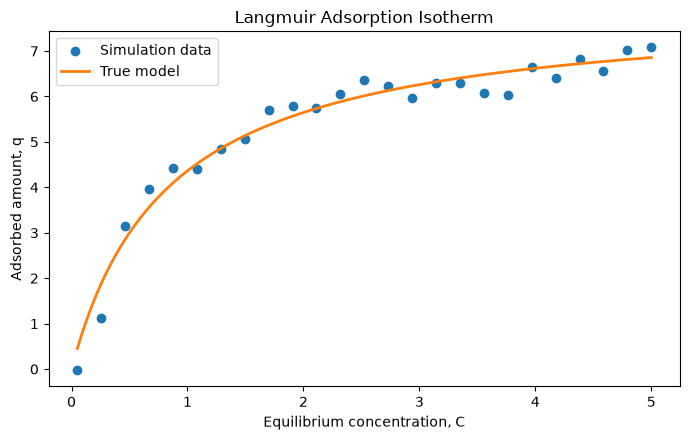

In [2]:
def langmuir(C, qmax, K):
    return qmax * K * C / (1 + K * C)


C = np.linspace(0.05, 5, 25)
rng_langmuir = np.random.default_rng(26)

qmax_true = 8.0
K_true = 1.2

q_clean = langmuir(C, qmax_true, K_true)
q_data = q_clean + rng_langmuir.normal(0, 0.25, C.size)

C_plot = np.linspace(C.min(), C.max(), 300)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.scatter(C, q_data, color="C0", label="Simulation data")
ax.plot(
    C_plot,
    langmuir(C_plot, qmax_true, K_true),
    color="C1",
    linewidth=2,
    label="True model",
)

ax.set_xlabel("Equilibrium concentration, C")
ax.set_ylabel("Adsorbed amount, q")
ax.set_title("Langmuir Adsorption Isotherm")
ax.legend()

fig.tight_layout()
plt.show()


### 1.1 Add physical bounds

Negative values of $q_{\max}$ or $K$ do not make physical sense here, so both parameters are constrained to be nonnegative.

For this dataset, the unconstrained solution is already positive. The two fits therefore overlap. The bounds still prevent the optimizer from accepting an unphysical solution in a harder problem.


,fit,qmax,K
0,Without bounds,7.8795,1.2807
1,With bounds,7.8795,1.2807


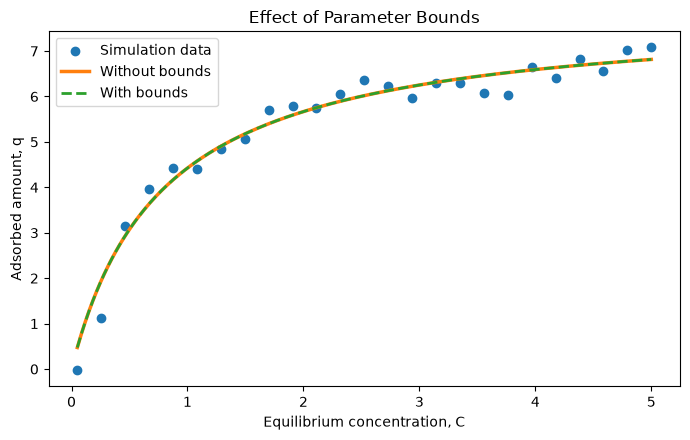

In [3]:
p0_langmuir = [5.0, 0.5]

popt_unbounded, pcov_unbounded = curve_fit(
    langmuir,
    C,
    q_data,
    p0=p0_langmuir,
)

popt_bounded, pcov_bounded = curve_fit(
    langmuir,
    C,
    q_data,
    p0=p0_langmuir,
    bounds=([0, 0], [np.inf, np.inf]),
)

langmuir_results = pd.DataFrame({
    "fit": ["Without bounds", "With bounds"],
    "qmax": [popt_unbounded[0], popt_bounded[0]],
    "K": [popt_unbounded[1], popt_bounded[1]],
})

display(langmuir_results.round(4))

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.scatter(C, q_data, color="C0", label="Simulation data")
ax.plot(
    C_plot,
    langmuir(C_plot, *popt_unbounded),
    color="C1",
    linewidth=2.5,
    label="Without bounds",
)
ax.plot(
    C_plot,
    langmuir(C_plot, *popt_bounded),
    color="C2",
    linestyle="--",
    linewidth=2,
    label="With bounds",
)

ax.set_xlabel("Equilibrium concentration, C")
ax.set_ylabel("Adsorbed amount, q")
ax.set_title("Effect of Parameter Bounds")
ax.legend()

fig.tight_layout()
plt.show()


## 2. Initial guesses in a damped-signal model

Consider the damped signal

$$
y(t)=A\exp(-bt)\cos(\omega t+\phi)+c.
$$

$A$ is the initial amplitude, $b$ is the damping rate, $\omega$ is the oscillation frequency, $\phi$ is the phase shift, and $c$ is the final steady value.

Nonlinear fitting begins from an initial parameter guess. Different guesses may reach the same solution, different local solutions, or fail to converge.


In [4]:
def damped(t, A, b, omega, phi, c):
    return A * np.exp(-b * t) * np.cos(omega * t + phi) + c


t_signal = np.linspace(0, 12, 100)
rng_signal = np.random.default_rng(26)

theta_signal_true = [3.0, 0.10, 3.8, 0.45, 10.0]
y_signal_clean = damped(t_signal, *theta_signal_true)
y_signal = y_signal_clean + rng_signal.normal(0, 0.25, t_signal.size)

initial_guesses = {
    "Good guess": [2.8, 0.12, 3.6, 0.30, 10.0],
    "Low-frequency guess": [1.5, 0.30, 1.4, -0.50, 9.8],
    "High-frequency guess": [1.5, 0.30, 6.2, 0.80, 10.2],
}

colors = {
    "Good guess": "C0",
    "Low-frequency guess": "C1",
    "High-frequency guess": "C2",
}

lower_bounds = [0, 0, 0, -2 * np.pi, -np.inf]
upper_bounds = [np.inf, 2, 8, 2 * np.pi, np.inf]

signal_results = {}

for name, p0 in initial_guesses.items():
    popt, pcov = curve_fit(
        damped,
        t_signal,
        y_signal,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=30000,
    )

    residuals = y_signal - damped(t_signal, *popt)
    rmse = np.sqrt(np.mean(residuals**2))

    signal_results[name] = {
        "p0": p0,
        "popt": popt,
        "pcov": pcov,
        "rmse": rmse,
    }

signal_table = pd.DataFrame([
    {
        "initial guess": name,
        "A": result["popt"][0],
        "b": result["popt"][1],
        "omega": result["popt"][2],
        "phi": result["popt"][3],
        "c": result["popt"][4],
        "RMSE": result["rmse"],
    }
    for name, result in signal_results.items()
])

display(signal_table.round(4))


,initial guess,A,b,omega,phi,c,RMSE
0,Good guess,2.9745,0.0953,3.7887,0.5181,10.0224,0.2648
1,Low-frequency guess,2.9745,0.0953,3.7887,0.5181,10.0224,0.2648
2,High-frequency guess,2.9745,0.0953,3.7887,0.5181,10.0224,0.2648


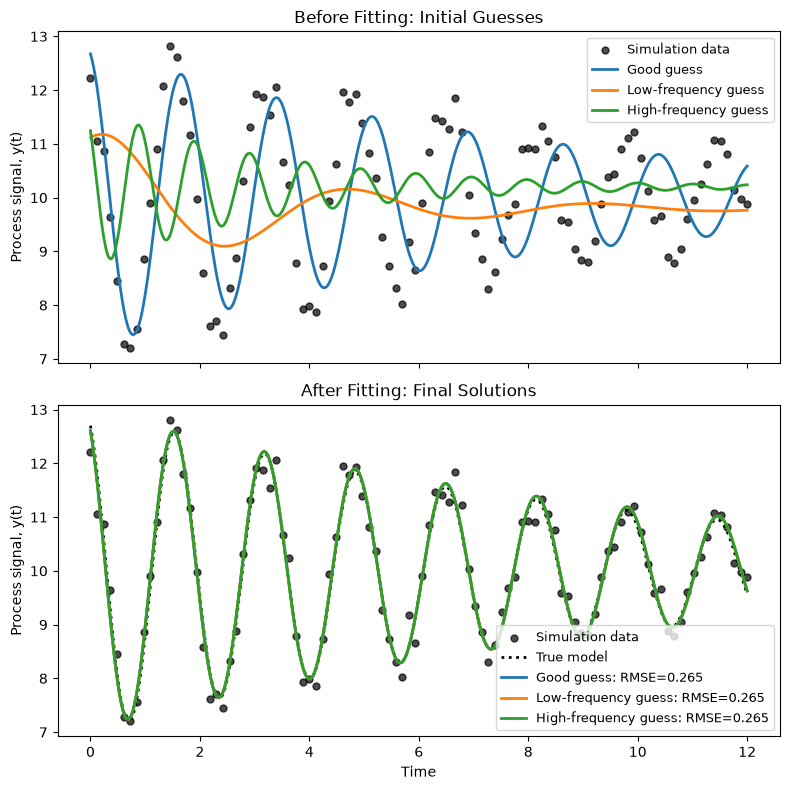

In [5]:
t_signal_plot = np.linspace(t_signal.min(), t_signal.max(), 800)

fig, ax = plt.subplots(
    2,
    1,
    figsize=(8, 8),
    sharex=True,
    sharey=True,
)

ax[0].scatter(
    t_signal,
    y_signal,
    color="black",
    s=25,
    alpha=0.7,
    label="Simulation data",
)

for name, result in signal_results.items():
    ax[0].plot(
        t_signal_plot,
        damped(t_signal_plot, *result["p0"]),
        color=colors[name],
        linewidth=2,
        label=name,
    )

ax[0].set_ylabel("Process signal, y(t)")
ax[0].set_title("Before Fitting: Initial Guesses")
ax[0].legend(fontsize=9)

ax[1].scatter(
    t_signal,
    y_signal,
    color="black",
    s=25,
    alpha=0.7,
    label="Simulation data",
)
ax[1].plot(
    t_signal_plot,
    damped(t_signal_plot, *theta_signal_true),
    color="black",
    linestyle=":",
    linewidth=2,
    label="True model",
)

for name, result in signal_results.items():
    ax[1].plot(
        t_signal_plot,
        damped(t_signal_plot, *result["popt"]),
        color=colors[name],
        linewidth=2,
        label=f'{name}: RMSE={result["rmse"]:.3f}',
    )

ax[1].set_xlabel("Time")
ax[1].set_ylabel("Process signal, y(t)")
ax[1].set_title("After Fitting: Final Solutions")
ax[1].legend(fontsize=9)

fig.tight_layout()
plt.show()


All three guesses reach nearly the same fitted curve in this example. That is useful evidence that this particular solution is stable to these starting points. It does not prove that every initial guess will work.

### 2.1 Choose an optimization method

| Method | Bounds | Typical use |
|---|---|---|
| `lm` | No | Small unconstrained problems |
| `trf` | Yes | Default choice when bounds are supplied |
| `dogbox` | Yes | Another bounded method for small problems |

`curve_fit` normally uses `lm` without bounds and `trf` when bounds are supplied. The method matters most when the problem is difficult, poorly scaled, or constrained.


## 3. Return to polymer stress relaxation

Notebook 06 fitted the Maxwell relaxation model

$$
\hat G(t;\theta)=G_0\exp\left(-\frac{t}{\tau}\right),
\qquad
\theta=[G_0,\tau]^T.
$$

Here we fit the same simulated experiment with `curve_fit` and then study the uncertainty in $G_0$ and $\tau$.


In [6]:
def maxwell_curve(t, G0, tau):
    return G0 * np.exp(-t / tau)


t = np.linspace(0, 5, 21)
rng_maxwell = np.random.default_rng(7)

G0_true = 10.0
tau_true = 1.5
sigma_true = 0.15

G_clean = maxwell_curve(t, G0_true, tau_true)
G_data = G_clean + rng_maxwell.normal(0, sigma_true, t.size)

theta_initial = [8.0, 2.5]

theta_fit, covariance = curve_fit(
    maxwell_curve,
    t,
    G_data,
    p0=theta_initial,
    bounds=(0, np.inf),
)

parameter_se = np.sqrt(np.diag(covariance))

maxwell_results = pd.DataFrame({
    "parameter": ["G0", "tau"],
    "true value": [G0_true, tau_true],
    "estimate": theta_fit,
    "standard error": parameter_se,
})

display(maxwell_results.round(4))


,parameter,true value,estimate,standard error
0,G0,10.0,10.0224,0.0955
1,tau,1.5,1.4740,0.0219


### 3.1 Show the best fit and nearby parameter choices

`curve_fit` returns the fitted parameters in `theta_fit` and their approximate covariance matrix in `covariance`. Sampling from that local covariance gives a visual sense of how much the fitted curve can move.

These thin curves are a visual sample of nearby fits. They are not a 95% confidence band.


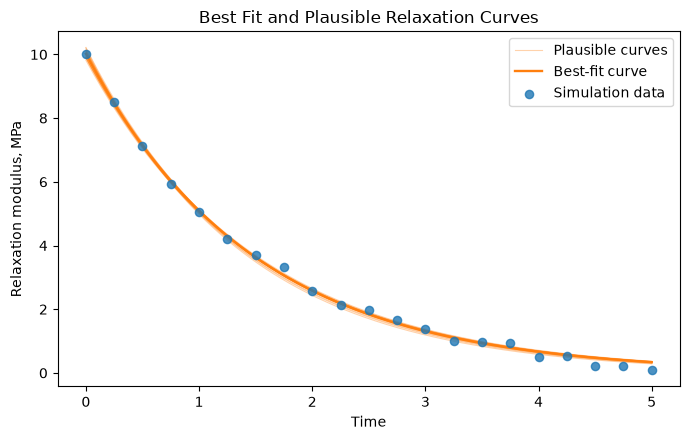

In [7]:
t_plot = np.linspace(t.min(), t.max(), 300)
G_fit_plot = maxwell_curve(t_plot, *theta_fit)

rng_curves = np.random.default_rng(26)
parameter_samples = rng_curves.multivariate_normal(
    mean=theta_fit,
    cov=covariance,
    size=15,
)

fig, ax = plt.subplots(figsize=(7, 4.5))

for i, (G0_sample, tau_sample) in enumerate(parameter_samples):
    ax.plot(
        t_plot,
        maxwell_curve(t_plot, G0_sample, tau_sample),
        color="C1",
        linewidth=0.8,
        alpha=0.35,
        label="Plausible curves" if i == 0 else None,
    )

ax.plot(
    t_plot,
    G_fit_plot,
    color="C1",
    linewidth=1.7,
    label="Best-fit curve",
)
ax.scatter(
    t,
    G_data,
    color="C0",
    s=35,
    alpha=0.8,
    label="Simulation data",
    zorder=3,
)

ax.set_xlabel("Time")
ax.set_ylabel("Relaxation modulus, MPa")
ax.set_title("Best Fit and Plausible Relaxation Curves")
ax.legend()

fig.tight_layout()
plt.show()


## 4. Estimate measurement noise from residuals

Write each measurement as

$$
G_i=G_0\exp\left(-\frac{t_i}{\tau}\right)+\varepsilon_i,
\qquad
\varepsilon_i\overset{\mathrm{iid}}{\sim}\mathcal N(0,\sigma^2).
$$

The residual is the vertical gap between a measurement and the fitted curve:

$$
e_i=G_i-\hat G(t_i).
$$

We estimate the noise variance with

$$
s^2=\frac{\mathrm{SSE}}{n-p},
\qquad
\mathrm{SSE}=\sum_{i=1}^{n}e_i^2.
$$

Fitting $p$ parameters uses $p$ directions in the data, leaving $n-p$ residual degrees of freedom. For nonlinear regression, this is the usual local approximation.


SSE = 0.3473 MPa^2
s^2 = 0.0183 MPa^2
s = 0.1352 MPa


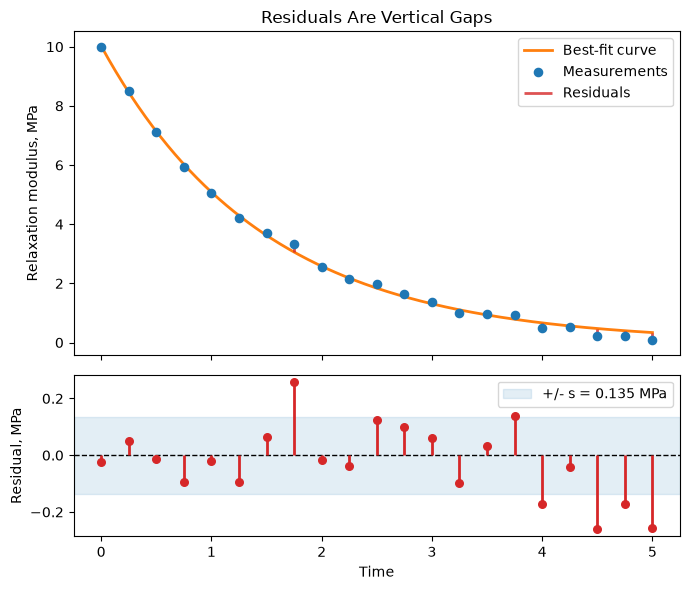

In [8]:
G_fit_data = maxwell_curve(t, *theta_fit)
residuals = G_data - G_fit_data

SSE = np.sum(residuals**2)
n = t.size
p = theta_fit.size
degrees_of_freedom = n - p

noise_variance = SSE / degrees_of_freedom
s = np.sqrt(noise_variance)

print(f"SSE = {SSE:.4f} MPa^2")
print(f"s^2 = {noise_variance:.4f} MPa^2")
print(f"s = {s:.4f} MPa")

fig, ax = plt.subplots(
    2,
    1,
    figsize=(7, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

ax[0].plot(
    t_plot,
    G_fit_plot,
    color="C1",
    linewidth=2,
    label="Best-fit curve",
)
ax[0].scatter(
    t,
    G_data,
    color="C0",
    s=35,
    label="Measurements",
    zorder=3,
)
ax[0].vlines(
    t,
    G_fit_data,
    G_data,
    color="C3",
    linewidth=2,
    alpha=0.8,
    label="Residuals",
)

ax[0].set_ylabel("Relaxation modulus, MPa")
ax[0].set_title("Residuals Are Vertical Gaps")
ax[0].legend()

ax[1].axhline(0, color="black", linestyle="--", linewidth=1)
ax[1].vlines(t, 0, residuals, color="C3", linewidth=2)
ax[1].scatter(t, residuals, color="C3", s=30, zorder=3)
ax[1].axhspan(
    -s,
    s,
    color="C0",
    alpha=0.12,
    label=f"+/- s = {s:.3f} MPa",
)

ax[1].set_xlabel("Time")
ax[1].set_ylabel("Residual, MPa")
ax[1].legend()

fig.tight_layout()
plt.show()


## 5. Covariance measures parameter uncertainty

For the linear model $\mathbf y=\mathbf X\theta+\varepsilon$, the estimated covariance matrix is

$$
\widehat{\mathrm{Cov}}(\hat\theta)
=s^2(\mathbf X^T\mathbf X)^{-1}.
$$

The diagonal entries are parameter variances. Their square roots are standard errors:

$$
\mathrm{SE}(\hat\theta_j)
=\sqrt{\left[\widehat{\mathrm{Cov}}(\hat\theta)\right]_{jj}}.
$$

In plain language, the covariance matrix records how much the fitted parameters would move if the experiment were repeated with new noise.


### 5.1 Why measurement range matters

For a line with an intercept, the slope standard error is

$$
\mathrm{SE}(\hat\beta_1)
=\frac{s}{\sqrt{\sum_{i=1}^{n}(x_i-\bar x)^2}}.
$$

The same number of measurements gives a more precise slope when the $x$ values cover a useful range.


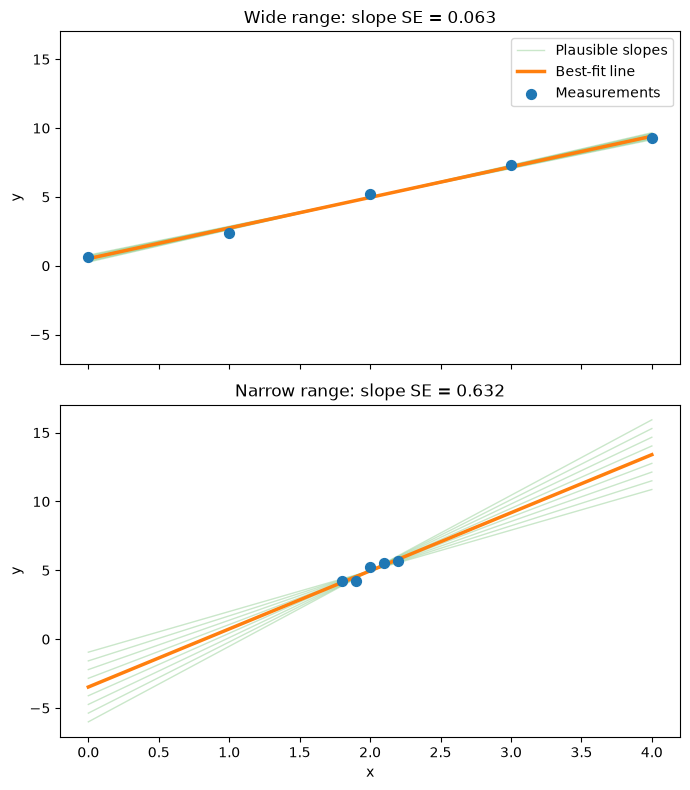

,range,Sxx,slope estimate,slope standard error
0,Wide range,10.0,2.222,0.063
1,Narrow range,0.1,4.218,0.632


In [9]:
rng_line = np.random.default_rng(26)

sigma_line = 0.20
beta0_true = 1.0
beta1_true = 2.0

x_wide = np.array([0, 1, 2, 3, 4], dtype=float)
x_narrow = np.array([1.8, 1.9, 2.0, 2.1, 2.2])

shared_noise = rng_line.normal(0, sigma_line, 5)

y_wide = beta0_true + beta1_true * x_wide + shared_noise
y_narrow = beta0_true + beta1_true * x_narrow + shared_noise

x_plot = np.linspace(0, 4, 300)
multipliers = np.array([-2.0, -1.5, -1.0, -0.5, 0.5, 1.0, 1.5, 2.0])

datasets = {
    "Wide range": (x_wide, y_wide),
    "Narrow range": (x_narrow, y_narrow),
}

range_results = []

fig, ax = plt.subplots(
    2,
    1,
    figsize=(7, 8),
    sharex=True,
    sharey=True,
)

for axis, (name, (x_values, y_values)) in zip(ax, datasets.items()):
    slope_hat, intercept_hat = np.polyfit(x_values, y_values, 1)

    x_mean = np.mean(x_values)
    y_mean = np.mean(y_values)
    Sxx = np.sum((x_values - x_mean) ** 2)
    slope_se = sigma_line / np.sqrt(Sxx)

    range_results.append({
        "range": name,
        "Sxx": Sxx,
        "slope estimate": slope_hat,
        "slope standard error": slope_se,
    })

    for i, multiplier in enumerate(multipliers):
        slope = slope_hat + multiplier * slope_se
        intercept = y_mean - slope * x_mean

        axis.plot(
            x_plot,
            intercept + slope * x_plot,
            color="C2",
            linewidth=1,
            alpha=0.25,
            label="Plausible slopes" if i == 0 else None,
        )

    axis.plot(
        x_plot,
        intercept_hat + slope_hat * x_plot,
        color="C1",
        linewidth=2.5,
        label="Best-fit line",
    )
    axis.scatter(
        x_values,
        y_values,
        color="C0",
        s=50,
        label="Measurements",
        zorder=3,
    )

    axis.set_ylabel("y")
    axis.set_title(f"{name}: slope SE = {slope_se:.3f}")

ax[1].set_xlabel("x")
ax[0].legend()

fig.tight_layout()
plt.show()

display(pd.DataFrame(range_results).round(3))


## 6. What a 95% confidence interval means

For a linear-regression parameter,

$$
\hat\theta_j
\pm t_{0.975,n-p}\,\mathrm{SE}(\hat\theta_j)
$$

is a 95% confidence interval. If the complete experiment were repeated many times, about 95% of the intervals built this way would contain the fixed true parameter.

The parameter does not change from experiment to experiment. The estimate and its interval change because the measurements contain new noise.


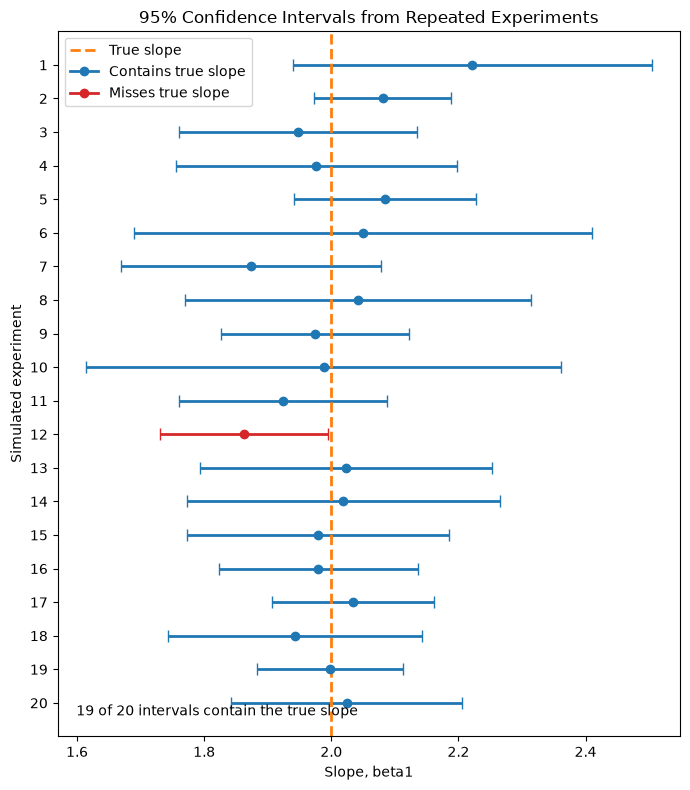

In [10]:
rng_intervals = np.random.default_rng(26)

x_ci = np.array([0, 1, 2, 3, 4], dtype=float)
n_experiments = 20
n_ci = x_ci.size
p_ci = 2
df_ci = n_ci - p_ci

Sxx_ci = np.sum((x_ci - np.mean(x_ci)) ** 2)
t_critical_ci = student_t.ppf(0.975, df_ci)

intervals = []

for experiment in range(n_experiments):
    y_ci = (
        beta0_true
        + beta1_true * x_ci
        + rng_intervals.normal(0, sigma_line, x_ci.size)
    )

    slope_hat, intercept_hat = np.polyfit(x_ci, y_ci, 1)
    y_fit_ci = intercept_hat + slope_hat * x_ci
    residuals_ci = y_ci - y_fit_ci

    s_ci = np.sqrt(np.sum(residuals_ci**2) / df_ci)
    slope_se_ci = s_ci / np.sqrt(Sxx_ci)

    lower = slope_hat - t_critical_ci * slope_se_ci
    upper = slope_hat + t_critical_ci * slope_se_ci

    intervals.append({
        "estimate": slope_hat,
        "lower": lower,
        "upper": upper,
        "contains true": lower <= beta1_true <= upper,
    })

fig, ax = plt.subplots(figsize=(7, 8))

for i, interval in enumerate(intervals, start=1):
    color = "C0" if interval["contains true"] else "C3"

    ax.errorbar(
        interval["estimate"],
        i,
        xerr=[
            [interval["estimate"] - interval["lower"]],
            [interval["upper"] - interval["estimate"]],
        ],
        fmt="o",
        color=color,
        capsize=4,
        linewidth=2,
        markersize=6,
    )

ax.axvline(beta1_true, color="C1", linestyle="--", linewidth=2)

n_containing = sum(interval["contains true"] for interval in intervals)

ax.text(
    0.03,
    0.03,
    f"{n_containing} of {n_experiments} intervals contain the true slope",
    transform=ax.transAxes,
)

legend_handles = [
    Line2D([0], [0], color="C1", linestyle="--", linewidth=2, label="True slope"),
    Line2D([0], [0], color="C0", marker="o", linewidth=2, label="Contains true slope"),
    Line2D([0], [0], color="C3", marker="o", linewidth=2, label="Misses true slope"),
]

ax.set_xlabel("Slope, beta1")
ax.set_ylabel("Simulated experiment")
ax.set_title("95% Confidence Intervals from Repeated Experiments")
ax.set_yticks(np.arange(1, n_experiments + 1))
ax.set_ylim(0, n_experiments + 1)
ax.invert_yaxis()
ax.legend(handles=legend_handles)

fig.tight_layout()
plt.show()


## 7. Nonlinear covariance comes from a local linear approximation

Near the fitted parameters, a nonlinear model can be approximated by

$$
\mathbf f(\hat\theta+\Delta\theta)
\approx
\mathbf f(\hat\theta)+\mathbf J\Delta\theta,
$$

where $\mathbf J$ is the Jacobian evaluated at $\hat\theta$. This gives the local approximation

$$
\widehat{\mathrm{Cov}}(\hat\theta)
\approx s^2(\mathbf J^T\mathbf J)^{-1}.
$$

SciPy returns this approximate covariance as `covariance`. The square roots of its diagonal entries are the parameter standard errors.


In [11]:
t_critical = student_t.ppf(0.975, degrees_of_freedom)

ci_lower = theta_fit - t_critical * parameter_se
ci_upper = theta_fit + t_critical * parameter_se

parameter_intervals = pd.DataFrame({
    "parameter": ["G0", "tau"],
    "estimate": theta_fit,
    "standard error": parameter_se,
    "lower 95%": ci_lower,
    "upper 95%": ci_upper,
    "unit": ["MPa", "s"],
})

display(parameter_intervals.round(4))


,parameter,estimate,standard error,lower 95%,upper 95%,unit
0,G0,10.0224,0.0955,9.8225,10.2223,MPa
1,tau,1.4740,0.0219,1.4281,1.5198,s


## 8. Mean-response uncertainty and prediction uncertainty

At one fixed time, two questions are possible:

1. Where is the mean model response?
2. Where might one new measurement fall?

For the nonlinear Maxwell model, let $\mathbf g$ be the gradient of $G(t)$ with respect to $[G_0,\tau]^T$. Then

$$
\mathrm{Var}(\hat G_{\mathrm{mean}})
\approx \mathbf g^T\,\mathrm{pcov}\,\mathbf g.
$$

A new measurement also contains measurement noise, so its variance is approximately

$$
\mathrm{Var}(G_{\mathrm{new}})
\approx \mathbf g^T\,\mathrm{pcov}\,\mathbf g+s^2.
$$

This is why the prediction interval is wider.

The visual below uses a second simulated experiment with $\sigma=0.35$ and random seed 6 so the difference between the two intervals is easy to see.


Fitted mean at t = 2.0 s: 2.782 MPa
95% confidence interval for mean: [2.529, 3.035] MPa
95% prediction interval: [1.894, 3.669] MPa


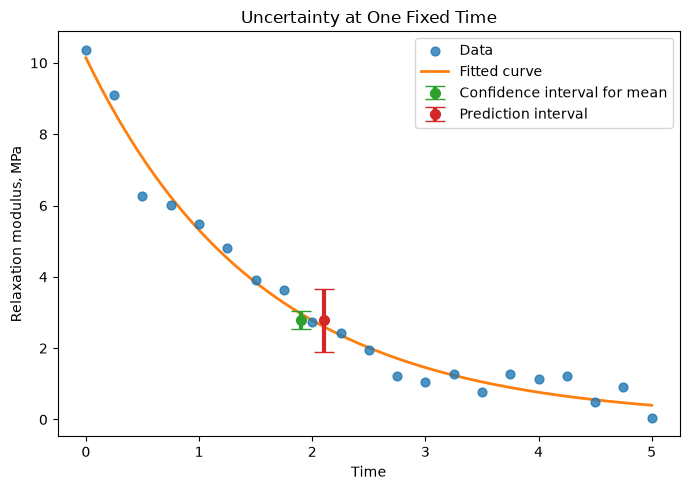

In [12]:
rng_prediction = np.random.default_rng(6)

sigma_prediction = 0.35
t_fixed = 2.0

G_prediction_data = G_clean + rng_prediction.normal(
    0,
    sigma_prediction,
    t.size,
)

theta_prediction, covariance_prediction = curve_fit(
    maxwell_curve,
    t,
    G_prediction_data,
    p0=theta_initial,
    bounds=(0, np.inf),
)

G_prediction_fit_data = maxwell_curve(t, *theta_prediction)
prediction_residuals = G_prediction_data - G_prediction_fit_data

s_prediction = np.sqrt(
    np.sum(prediction_residuals**2)
    / degrees_of_freedom
)

G0_prediction, tau_prediction = theta_prediction
exponential = np.exp(-t_fixed / tau_prediction)

gradient = np.array([
    exponential,
    G0_prediction * exponential * t_fixed / tau_prediction**2,
])

mean_se = np.sqrt(
    gradient
    @ covariance_prediction
    @ gradient
)

new_measurement_se = np.sqrt(mean_se**2 + s_prediction**2)

mean_half_width = t_critical * mean_se
prediction_half_width = t_critical * new_measurement_se

G_mean = maxwell_curve(t_fixed, *theta_prediction)

mean_interval = (
    G_mean - mean_half_width,
    G_mean + mean_half_width,
)
prediction_interval = (
    G_mean - prediction_half_width,
    G_mean + prediction_half_width,
)

print(f"Fitted mean at t = {t_fixed:.1f} s: {G_mean:.3f} MPa")
print(
    "95% confidence interval for mean: "
    f"[{mean_interval[0]:.3f}, {mean_interval[1]:.3f}] MPa"
)
print(
    "95% prediction interval: "
    f"[{prediction_interval[0]:.3f}, {prediction_interval[1]:.3f}] MPa"
)

t_prediction_plot = np.linspace(t.min(), t.max(), 300)
G_prediction_fit_plot = maxwell_curve(
    t_prediction_plot,
    *theta_prediction,
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    t,
    G_prediction_data,
    color="C0",
    s=40,
    alpha=0.8,
    label="Data",
    zorder=3,
)
ax.plot(
    t_prediction_plot,
    G_prediction_fit_plot,
    color="C1",
    linewidth=2,
    label="Fitted curve",
)
ax.errorbar(
    t_fixed - 0.10,
    G_mean,
    yerr=mean_half_width,
    fmt="o",
    color="C2",
    capsize=7,
    linewidth=3,
    markersize=7,
    label="Confidence interval for mean",
)
ax.errorbar(
    t_fixed + 0.10,
    G_mean,
    yerr=prediction_half_width,
    fmt="o",
    color="C3",
    capsize=7,
    linewidth=3,
    markersize=7,
    label="Prediction interval",
)

ax.set_xlabel("Time")
ax.set_ylabel("Relaxation modulus, MPa")
ax.set_title("Uncertainty at One Fixed Time")
ax.legend()

fig.tight_layout()
plt.show()
